# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


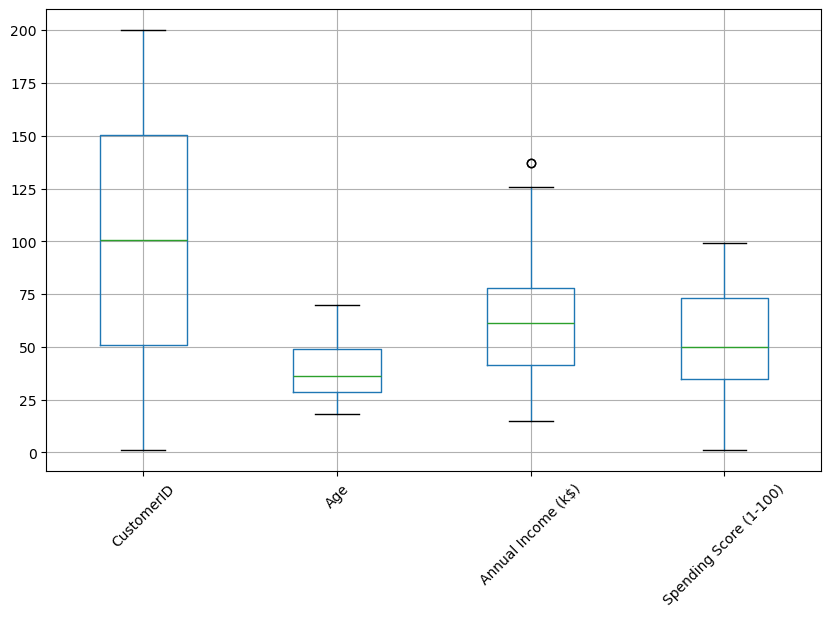

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200,200.000000,200.000000,200.000000
unique,NaN,2,NaN,NaN,NaN
top,NaN,Female,NaN,NaN,NaN
freq,NaN,112,NaN,NaN,NaN
mean,100.500000,NaN,38.850000,60.560000,50.200000
std,57.879185,NaN,13.969007,26.264721,25.823522
min,1.000000,NaN,18.000000,15.000000,1.000000
25%,50.750000,NaN,28.750000,41.500000,34.750000
50%,100.500000,NaN,36.000000,61.500000,50.000000
75%,150.250000,NaN,49.000000,78.000000,73.000000


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler


# Carregando o dataset
df = pd.read_csv('Mall_Customers.csv')

df.head()

# Dimensão do dataset
print('Shape:', df.shape)

# Primeiras linhas
display(df.head())

# Últimas linhas
display(df.tail())

# Informações gerais
df.info()

# Contagem de valores não nulos
df.count()

#tratamento de tipos
df.dtypes
df['Gender'] = df['Gender'].astype('category')

#dados faltantes
# Quantidade absoluta
df.isnull().sum()

# Percentual
(df.isnull().sum() / len(df)) * 100

#duplicados
# Total de duplicados
df.duplicated().sum()

# Visualizar duplicados (se houver)
df[df.duplicated()]

df.describe()

#IDENTIFICACAO DE OUTLIERS
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10,6))
df[colunas_numericas].boxplot()
plt.xticks(rotation=45)
plt.show()

#MÉTODO IQR
Q1 = df[colunas_numericas].quantile(0.25)
Q3 = df[colunas_numericas].quantile(0.75)
IQR = Q3 - Q1

outliers = ((df[colunas_numericas] < (Q1 - 1.5 * IQR)) | 
            (df[colunas_numericas] > (Q3 + 1.5 * IQR)))

outliers.sum()

df.describe(include='all')

**Análises descritivas, identificação de padrões, e verificação da presença de valores ausentes ou inconsistências que precisem ser tratadas**

C:\Users\Vivian\AppData\Local\Temp\ipykernel_14124\831042627.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()


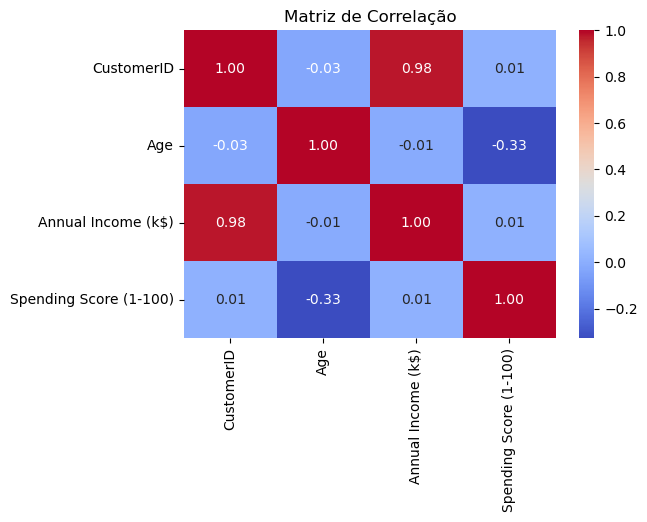

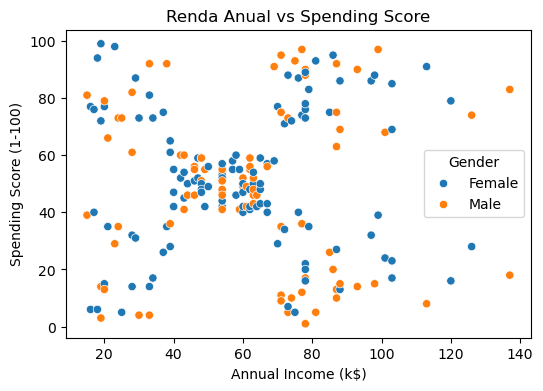

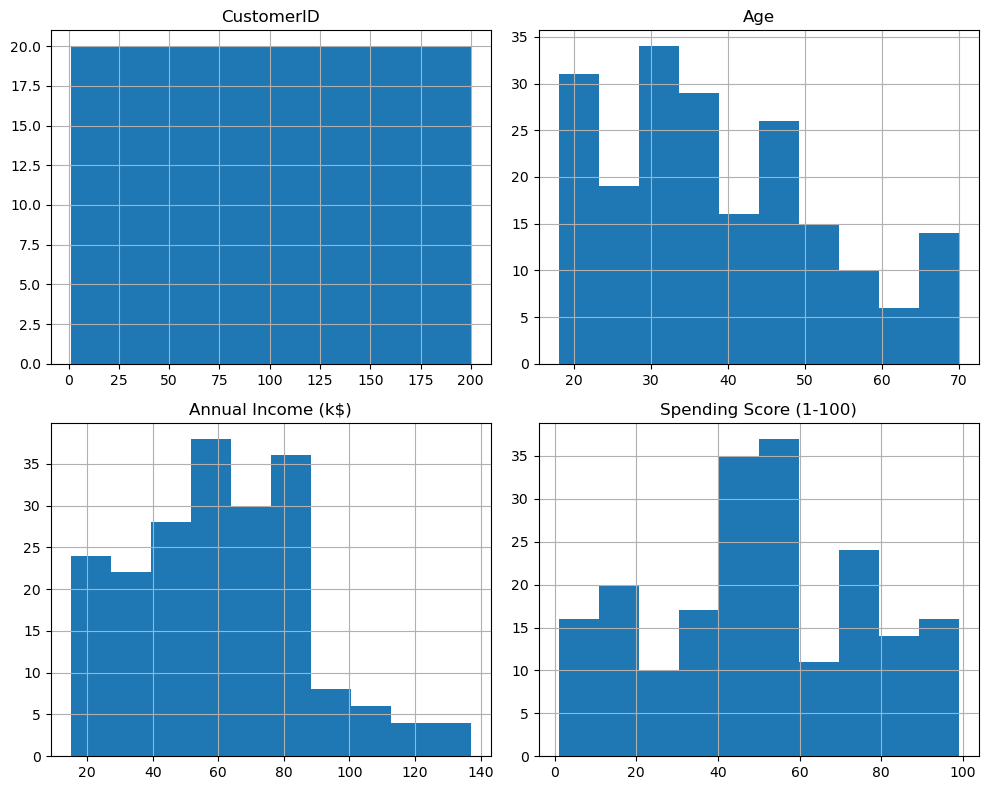

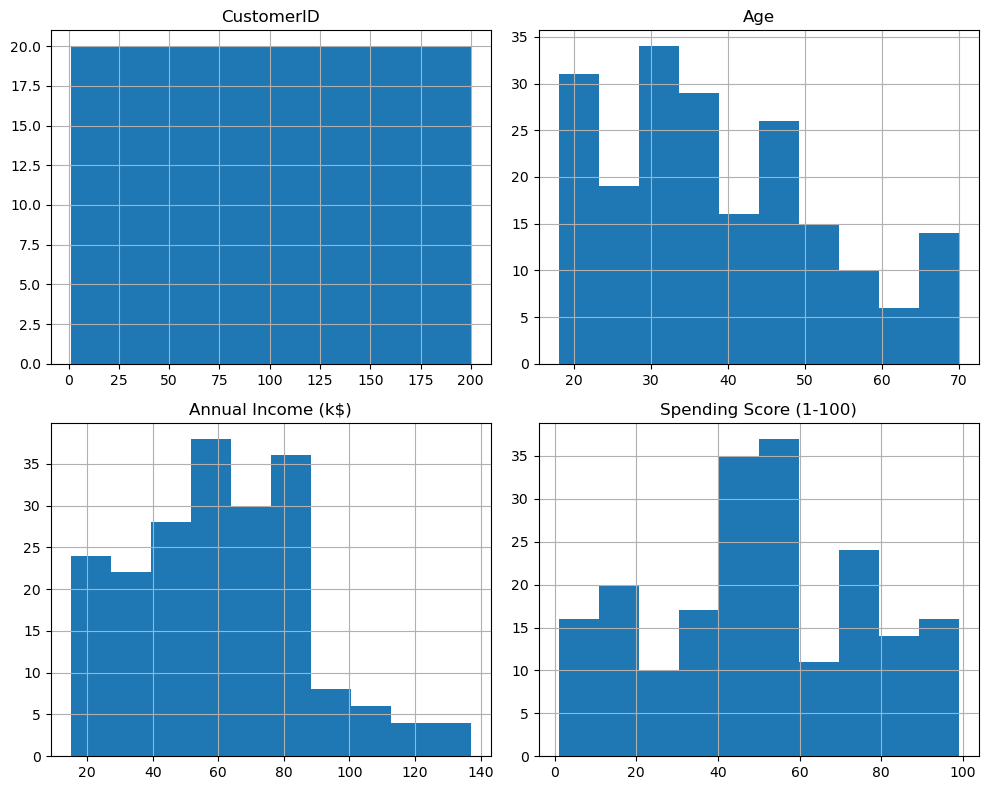

,Age,Annual Income (k$),Spending Score (1-100)
min,18,15,1
max,70,137,99


In [4]:
#Distribuição por gênero
df['Gender'].value_counts()

# Percentual
df['Gender'].value_counts(normalize=True) * 100

#Média por gênero
df.groupby('Gender')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()

#Correlação
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlação')
plt.show()

#Relação de RENDA vs SPENDING SCORE
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, 
                x='Annual Income (k$)', 
                y='Spending Score (1-100)', 
                hue='Gender')

plt.title('Renda Anual vs Spending Score')
plt.show()

df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

#DISTRIBUIÇÃO DAS VARIAVEIS NUMERICAS
df.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

# Quantidade absoluta
df.isnull().sum()

# Percentual
(df.isnull().sum() / len(df)) * 100

#INCONSISTENCIAS
df['Gender'].unique()

df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].agg(['min','max'])

# Tratamento de Dados

**Tratamentos necessários como: limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.**

In [29]:
#TRATAMENTO

if 'CustomerID' in df.columns:
    df = df.drop(columns=['CustomerID'])

#MODELO COMPORTAMENTAL
df_A = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler_A = StandardScaler()

df_A_scaled = scaler_A.fit_transform(df_A)
df_A_scaled = pd.DataFrame(df_A_scaled, columns=df_A.columns)

df_A_scaled.head()



,Age,Annual Income (k$),Spending Score (1-100)
0,-1.424569,-1.738999,-0.434801
1,-1.281035,-1.738999,1.195704
2,-1.352802,-1.700830,-1.715913
3,-1.137502,-1.700830,1.040418
4,-0.563369,-1.662660,-0.395980


**Etapas e explicação do tratamento**

A primeira etapa do projeto focou na limpeza e seleção de variáveis. Removemos o CustomerID, pois identificadores numéricos não carregam valor comportamental; mantê-los no modelo causaria um "ruído" artificial, distorcendo os cálculos de distância do algoritmo K-Means.
Para a segmentação, selecionamos três pilares essenciais: Idade (demografia), Renda Anual (capacidade financeira) e Pontuação de Gastos (comportamento real). Como essas variáveis possuem escalas muito diferentes — a renda chega aos milhares enquanto a idade é dezena — aplicamos a padronização (StandardScaler). Isso garante que nenhuma variável domine o cálculo sozinha, permitindo que o algoritmo trate todas com a mesma importância.

Insights Prévios:

Mesmo antes da clusterização, a base de dados já revela padrões interessantes:

Renda vs. Gasto: Clientes com alta renda são polarizados; ou gastam muito, ou são muito conservadores. A renda, isoladamente, não explica o consumo.
Baixa Renda: Esse grupo tende a um gasto moderado, raramente atingindo os extremos de pontuação.
Fator Geracional: Observa-se que o público mais jovem costuma ter maior propensão ao consumo do que os clientes mais velhos.
Em suma, os dados não são aleatórios. Eles possuem uma estrutura natural que o K-Means agora irá formalizar matematicamente, transformando essas tendências visíveis em grupos de consumidores bem definidos.


# Implementação do Algoritmo K-Means:
Aplicando o algoritmo K-Means no dataset tratado com definição de número de clusters.
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

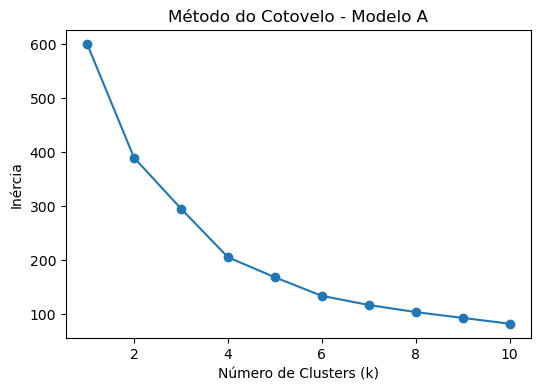

C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

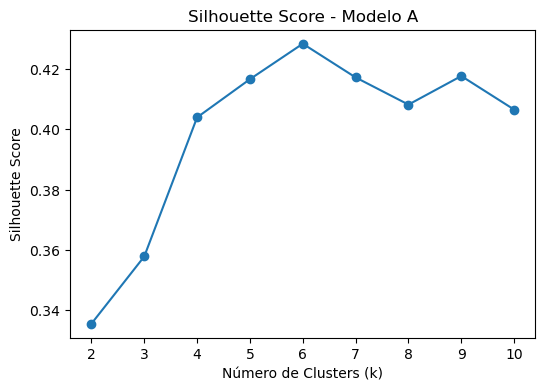

In [33]:
#MÉTODO COTOVELO
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_A_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo - Modelo A')
plt.show()

#SILHOUETTE SCORE
silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_A_scaled)
    score = silhouette_score(df_A_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(6,4))
plt.plot(range(2,11), silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score - Modelo A')
plt.show()


* Insights:

No gráfico do método do cotovelo, observa-se uma redução acentuada entre k = 1 e k = 4. A partir de k = 5 a curva começa a suavizar e, depois de k = 6, o ganho torna-se pequeno. O visual mais claro ocorre entre k = 4 e k = 5, com estabilização após k = 6.

No gráfico de Silhouette Score, o valor máximo ocorre em k = 6 (aproximadamente 0.43). Esse ponto representa a melhor separação média entre clusters, indicando maior coesão interna e maior separação entre grupos. Após k = 6, o índice começa a oscilar e não apresenta melhora consistente.

Combinando os dois critérios:

O cotovelo sugere algo entre 4 e 6.
O Silhouette indica claramente k = 6 como melhor valor.

Portanto, tecnicamente, o melhor K é 6.

In [37]:
#AJUSTE FINAL DO K-MEANS COM 6

k_final = 6

kmeans_final = KMeans(
    n_clusters=k_final,
    random_state=42,
    n_init=10
)

clusters = kmeans_final.fit_predict(df_A_scaled)

df_A['Cluster'] = clusters

df_A.head()

#Centróides
centroides = scaler_A.inverse_transform(kmeans_final.cluster_centers_)
centroides = pd.DataFrame(
    centroides,
    columns=['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
)

centroides

C:\Users\Vivian\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,Age,Annual Income (k$),Spending Score (1-100)
0,56.333333,54.266667,49.066667
1,26.794872,57.102564,48.128205
2,41.939394,88.939394,16.969697
3,32.692308,86.538462,82.128205
4,25.000000,25.260870,77.608696
5,45.523810,26.285714,19.380952


**Avaliação e Interpretação dos Resultados:**

Cluster 0: Idade média ≈ 56 anos // Renda média ≈ 54k // Spending Score ≈ 49

Perfil maduro, renda intermediária e comportamento de consumo moderado. São clientes mais velhos, estáveis, com padrão de gasto equilibrado.
Tendem a ser consumidores conservadores e previsíveis.

-----------------------------

Cluster 1: Idade média ≈ 27 anos // Renda média ≈ 57k // Spending Score ≈ 48

Jovens com renda média e consumo moderado. Perfil economicamente ativo, ainda não altamente consumista. Potencial de crescimento de consumo no longo prazo.

------------------------------

Cluster 2: Idade média ≈ 42 anos // Renda média ≈ 89k // Spending Score ≈ 17

Alta renda, baixo gasto. Perfil extremamente interessante estrategicamente. São clientes com poder aquisitivo elevado, mas baixo engajamento de consumo. Representam oportunidade de ativação e aumento de ticket médio.

-------------------------------

Cluster 3: Idade média ≈ 33 anos // Renda média ≈ 86k // Spending Score ≈ 82

Alta renda, alto gasto. Clientes premium. São o grupo mais valioso financeiramente. Provavelmente respondem bem a produtos exclusivos e experiências diferenciadas.

--------------------------------

Cluster 4: Idade média ≈ 25 anos // Renda média ≈ 25k // Spending Score ≈ 77

Baixa renda, alto gasto. Perfil impulsivo ou altamente orientado a consumo. Possível público jovem, sensível a tendências e marketing.

---------------------------------

Cluster 5: Idade média ≈ 45 anos // Renda média ≈ 26k // Spending Score ≈ 19

Baixa renda, baixo gasto. Grupo de menor valor comercial imediato. Perfil econômico mais restrito e consumo limitado.


A análise estrutural confirmou que o modelo capturou com precisão a organização natural do dataset Mall Customers. A identificação de seis grupos distintos (k = 6) mostrou-se a escolha mais fiel aos dados, revelando os seguintes perfis:

Extremos Financeiros: Dois grupos de alta renda (um com alto consumo e outro mais conservador) e dois de baixa renda (também divididos entre alto e baixo gasto).

Segmento Intermediário: Dois grupos de classe média, diferenciados principalmente pela faixa etária, o que adiciona uma camada demográfica importante à estratégia.

Conclusão Técnica: A escolha desse número de grupos é sustentada pelo Coeficiente de Silhouette, que atingiu seu ponto máximo em 6 clusters, indicando uma separação clara e sem sobreposições confusas. O resultado final não é apenas matematicamente sólido, mas também economicamente interpretável, oferecendo segmentações reais que podem guiar decisões de marketing e atendimento personalizado.


Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.